In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


In [2]:
df = pd.read_excel("..\data\OnlineRetail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
print("Unique customers:", df["CustomerID"].nunique())
print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique timestamps:", df["InvoiceDate"].nunique())

Unique customers: 4338
Unique invoices: 18532
Unique timestamps: 17282


### Adding a snapshot date to better calculate the recency data

In [13]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [14]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days= 1 )

In [15]:
snapshot_date

Timestamp('2011-12-10 12:50:00')

### we want data per customer so

In [16]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [17]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [18]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [19]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

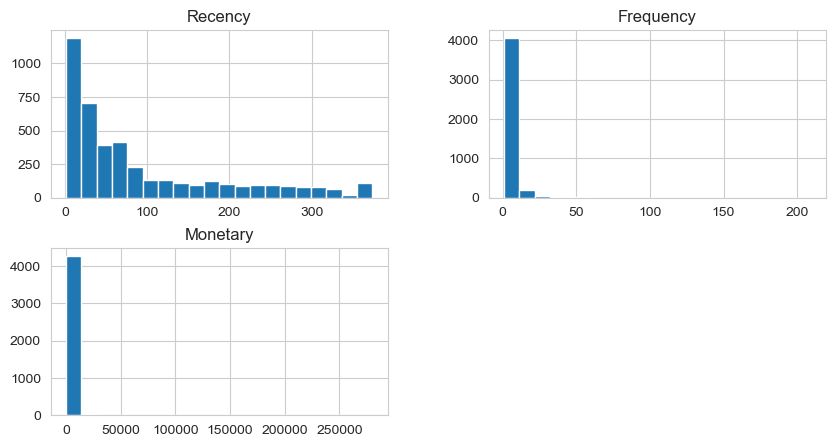

In [20]:
rfm.hist(figsize=(10,5),bins = 20)

### the data looks skewed , hence we can tranform the data to get a more balanced output that still maintains the relationship between the distributions

In [21]:
rfm_log = np.log1p(rfm)

array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

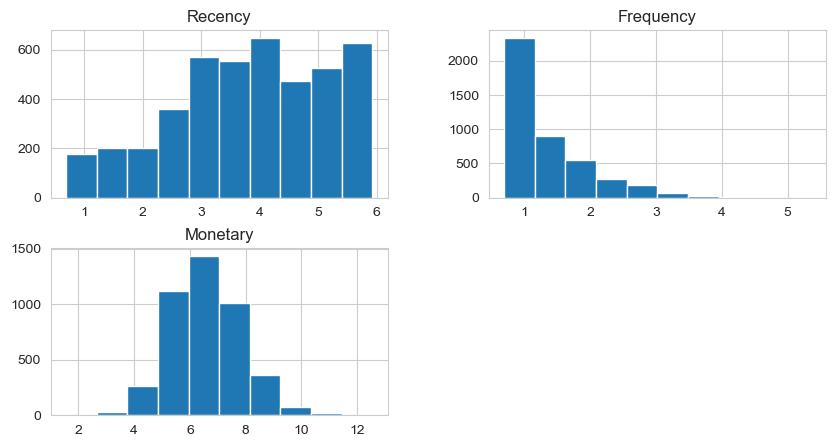

In [22]:
rfm_log.hist(figsize=(10,5))

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [24]:
rfm_scaled

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]])

### Converting back to a dataframe

In [25]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

In [26]:
rfm_scaled

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962
...,...,...,...
18280.0,1.343533,-0.955214,-1.106875
18281.0,1.024749,-0.955214,-1.740933
18282.0,-1.218940,-0.361583,-1.118121


In [27]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,2.817274e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-4.004574e+00
25%,-6.613615e-01,-9.552143e-01,-6.856676e-01
50%,8.992557e-02,-3.615828e-01,-6.218718e-02
75%,8.447915e-01,6.532370e-01,6.541861e-01
max,1.564198e+00,5.858535e+00,4.731591e+00


# implimenting the Elbo method(choosing the number of clusters)

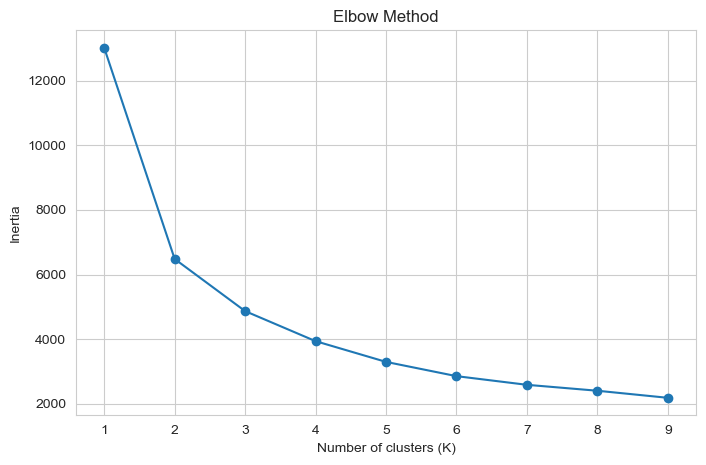

In [35]:
from  sklearn.cluster import KMeans
import matplotlib.pyplot as plt 

inertia = []
K = range(1,10)
for k in K:
    kmeans = KMeans(n_clusters= k,random_state = 42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### choosingg K = 4

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm_scaled['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [37]:
rfm_scaled.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,1.461993,-0.955214,3.706225,2
12347.0,-2.038734,1.074425,1.411843,1
12348.0,0.373104,0.386304,0.716489,2
12349.0,-0.623086,-0.955214,0.698739,0
12350.0,1.424558,-0.955214,-0.618962,3


### cluster profiles

In [38]:
rfm_analysis = rfm_scaled.groupby('Cluster').mean()
rfm_analysis

,Recency,Frequency,Monetary
Cluster,,,
0,-0.842774,-0.373167,-0.399286
1,-1.246333,1.658983,1.402351
2,0.138176,0.322086,0.523143
3,0.890630,-0.777480,-0.796233


In [39]:
rfm_scaled["Cluster"].value_counts()

Cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64

Customer segmentation using RFM analysis and K-Means clustering identified four distinct customer groups:

1. VIP Customers: Highly active, frequent buyers with high spending.
2. Regular Customers: Moderately active customers with average spending.
3. At-Risk Customers: Recently active but low engagement and spending.
4. Lost Customers: Inactive customers with low purchase frequency and spending.

This segmentation helps businesses target customers with personalized marketing strategies.